In [1]:
# setup and load libraries
import numpy as np
import main, cv2, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import MNIST
from inverse.orthogonal import LinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

SSIM = MetricSSIM(data_range=1.0, sigma=1.0, reduction=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Setup and Load Dataset

In [3]:
data = MNIST()
train_set = data.train_set()
test_set = data.test_set()

In [4]:
def show_image(image_set):
    n_row = 4
    n_col = 4
    fig, axs = plt.subplots(n_row, n_col, figsize=(n_col * 1, 
                            n_row * 1), sharex=True, sharey=True)

    for idx in range(n_row * n_col):
        axs.flat[idx].imshow(image_set[idx], cmap='gray')
        axs.flat[idx].axis('off')

    fig.tight_layout()

In [5]:
test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [6]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [7]:
model_path = './assets/unet_mnist.pt'
model = init_UNet({'num_blocks':2})
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

### PCA

In [8]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_
print('PCA Matrix', pcs.shape)

PCA Matrix (784, 784)


### OLM Performance

In [9]:
samples = [2, 4, 8, 16, 32, 64, 128, 256, 512]

base_path = './olm_result/MNIST/all_digit/%d_MSE_mnist.npy'

# record 4 different error metric
# pca projection, PCA + denoiser, rnd + denoiser, opt + denoiser
error = [np.zeros((2, len(samples))) for n in range(4)]

In [10]:
loss = torch.nn.MSELoss(reduction='sum')
def compute_loss(recon, test, test_torch):
    mse_val = (loss(test_torch, recon) / recon.shape[0]).item()
    recon_numpy = recon.permute([0, 2, 3, 1]).detach().cpu().numpy()
    psnr_val = psnr(test, recon_numpy)
    
    return mse_val, psnr_val

In [11]:
for index in tqdm(range(len(samples))):
    n_sample = samples[index]
    
    # setup linear inverse object
    solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
    solver.h_init = 0.10
    solver.beta = 0.10
    
    solver.run_avg = True
    solver.num_avg = 16
    recon_batch = 64
    
    # 1. PCA projection
    Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
    image_vec = test_torch.transpose(2, 3).flatten(1)
    recon_vec = image_vec @ Q.t() @ Q    

    # MSE
    error[0][0, index] = torch.sum((image_vec - recon_vec) ** 2) / image_vec.shape[0]
    # PSNR
    error[0][1, index] = psnr(image_vec.detach().cpu().numpy(), 
                              recon_vec.detach().cpu().numpy())
    
    # 2. PCA + Denoiser    
    solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
    solver_gpu = torch.nn.DataParallel(solver)    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[1][0, index] = loss_val[0]    
    error[1][1, index] = loss_val[1]
    
    # 3. Random Projection + Denoiser
    solver.assign(torch.rand(n_sample, np.prod(im_size)).to(device))
    solver_gpu = torch.nn.DataParallel(solver)
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[2][0, index] = loss_val[0]    
    error[2][1, index] = loss_val[1]

    # 4. Optimized Measuremnet + Denoiser
    order = 5
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)
        
    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    solver.assign(opt_mtx)
    solver_gpu = torch.nn.DataParallel(solver)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    error[3][0, index] = loss_val[0]
    error[3][1, index] = loss_val[1]

100%|█████████████████████████████████████████████████████████████████████████████████████| 9/9 [01:06<00:00,  7.41s/it]


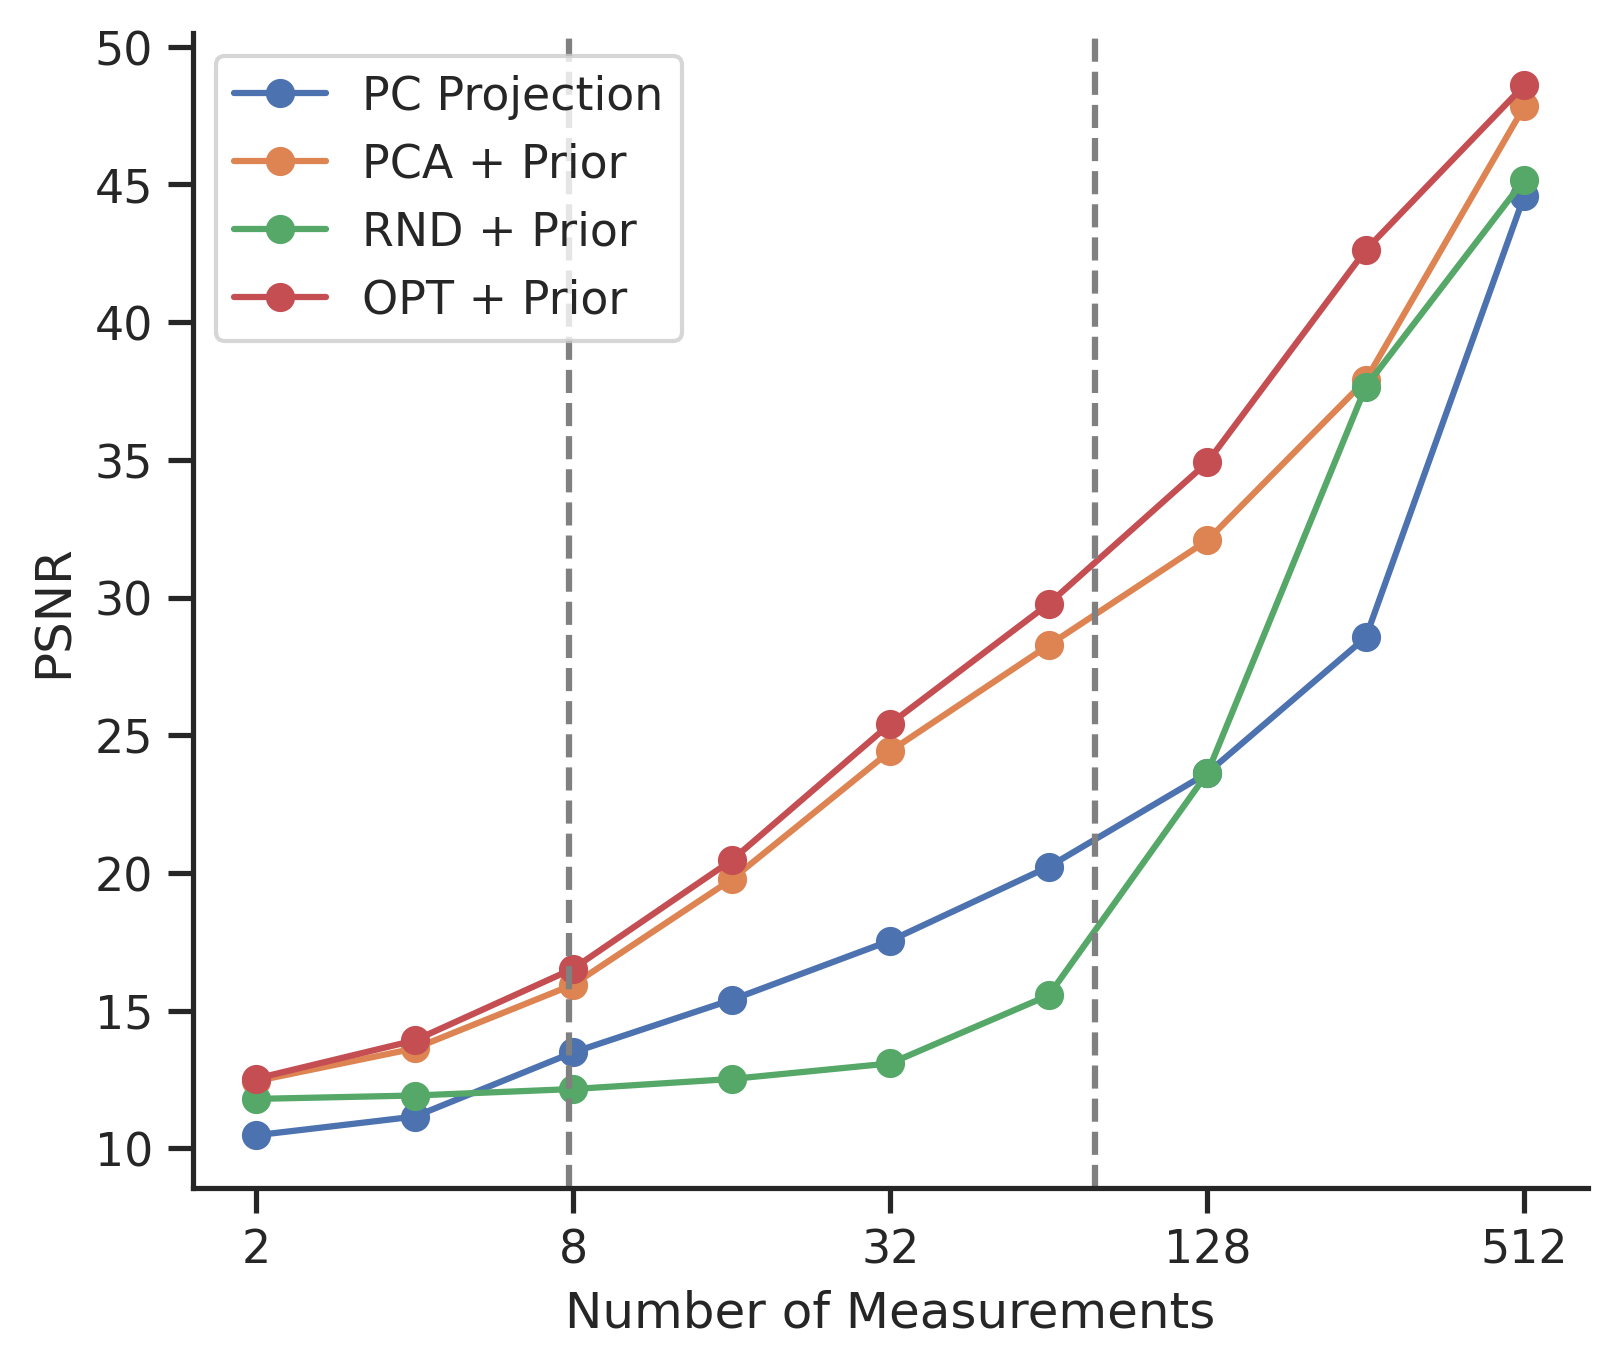

In [15]:
marker = [0.01, 0.1]

fig = plt.figure(figsize=(6, 5))

n_curve = 4
for idx in range(n_curve):
    plt.plot(samples, error[idx][1], '-o')

for mrk in marker:
    plt.axvline(mrk * n_pixel, linestyle ="--", color ='gray')

plt.xscale('log', base=2)
plt.xticks(2 ** np.array([1, 3, 5, 7, 9]),
          2 ** np.array([1, 3, 5, 7, 9]))

plt.xlabel('Number of Measurements')
plt.ylabel('PSNR')
plt.legend(['PC Projection', 'PCA + Prior', 
           'RND + Prior', 'OPT + Prior'])

if save_figure:
    fig_name = 'psnr_mnist'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')
    
plt.show()

Delta PSNR [0.0886665  0.29245635 0.58032998 0.69178386 0.99205634 1.50336286
 2.83131826 4.72592993 0.76624418]


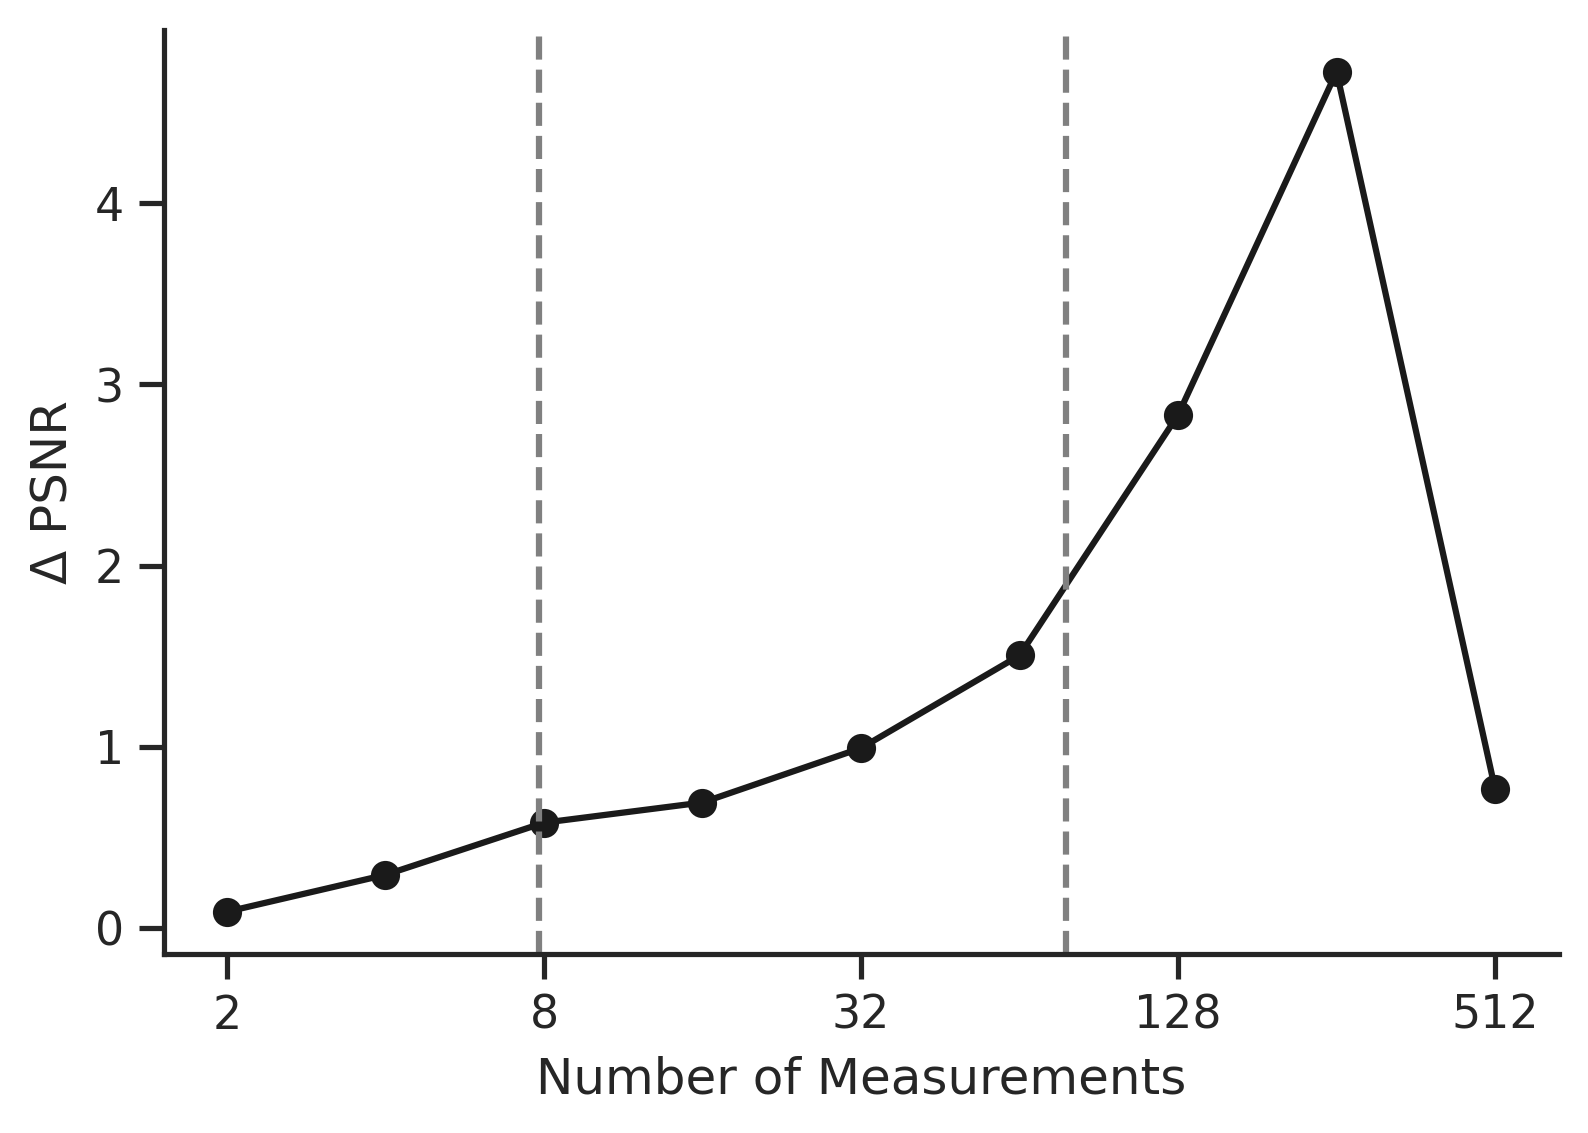

In [14]:
fig = plt.figure(figsize=(6, 4))

plt.plot(samples, error[3][1] - error[1][1],  '-ok')
print('Delta PSNR', error[3][1] - error[1][1])

for mrk in marker:
    plt.axvline(mrk * n_pixel, linestyle ="--", color ='gray')

plt.xscale('log', base=2)
plt.xticks(2 ** np.array([1, 3, 5, 7, 9]),
          2 ** np.array([1, 3, 5, 7, 9]))

plt.xlabel('Number of Measurements')
plt.ylabel('Δ PSNR')

if save_figure:
    fig_name = 'delta_psnr_mnist'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')
    
plt.show()

### Visual Comparsion

In [9]:
n_sample = 64

PCA

In [10]:
Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
image_vec = test_torch.transpose(2, 3).flatten(1)
recon_vec = image_vec @ Q.t() @ Q
recon_shape = [-1, im_size[0], im_size[2], im_size[1]]
recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)

recon_pca = recon_torch.detach().permute([0, 2, 3, 1]).cpu().numpy()
print(torch.sum((image_vec - recon_vec) ** 2) / image_vec.shape[0])

tensor(7.4453, device='cuda:0')


PCA + Prior

In [11]:
loss = torch.nn.MSELoss(reduction='sum')

solver = LinearInverse(n_sample, im_size, model, avg_im)
solver = solver.to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True 
solver.num_avg = 16

solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

recon_dns = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
print(loss(test_torch, recon) / recon.shape[0])

tensor(1.1616, device='cuda:0')


OLM + Prior

In [12]:
base_path = './olm_result/MNIST/all_digit/%d_MSE_mnist.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

In [13]:
opt_mtx = torch.from_numpy(opt_mtx).to(device)

solver.assign(opt_mtx)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

recon_opt = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
print(loss(test_torch, recon) / recon.shape[0])

tensor(0.8323, device='cuda:0')


Scatter Plot

In [14]:
psnr_dns = np.array([psnr(test_numpy[idx], recon_dns[idx]) 
            for idx in range(test_numpy.shape[0])])

psnr_opt = np.array([psnr(test_numpy[idx], recon_opt[idx]) 
            for idx in range(test_numpy.shape[0])])

In [15]:
# select a few images to show as example
psnr_index = np.argsort(psnr_opt - psnr_dns)
index_best = psnr_index[-10:][::-1]
index_select = np.concatenate([index_best])

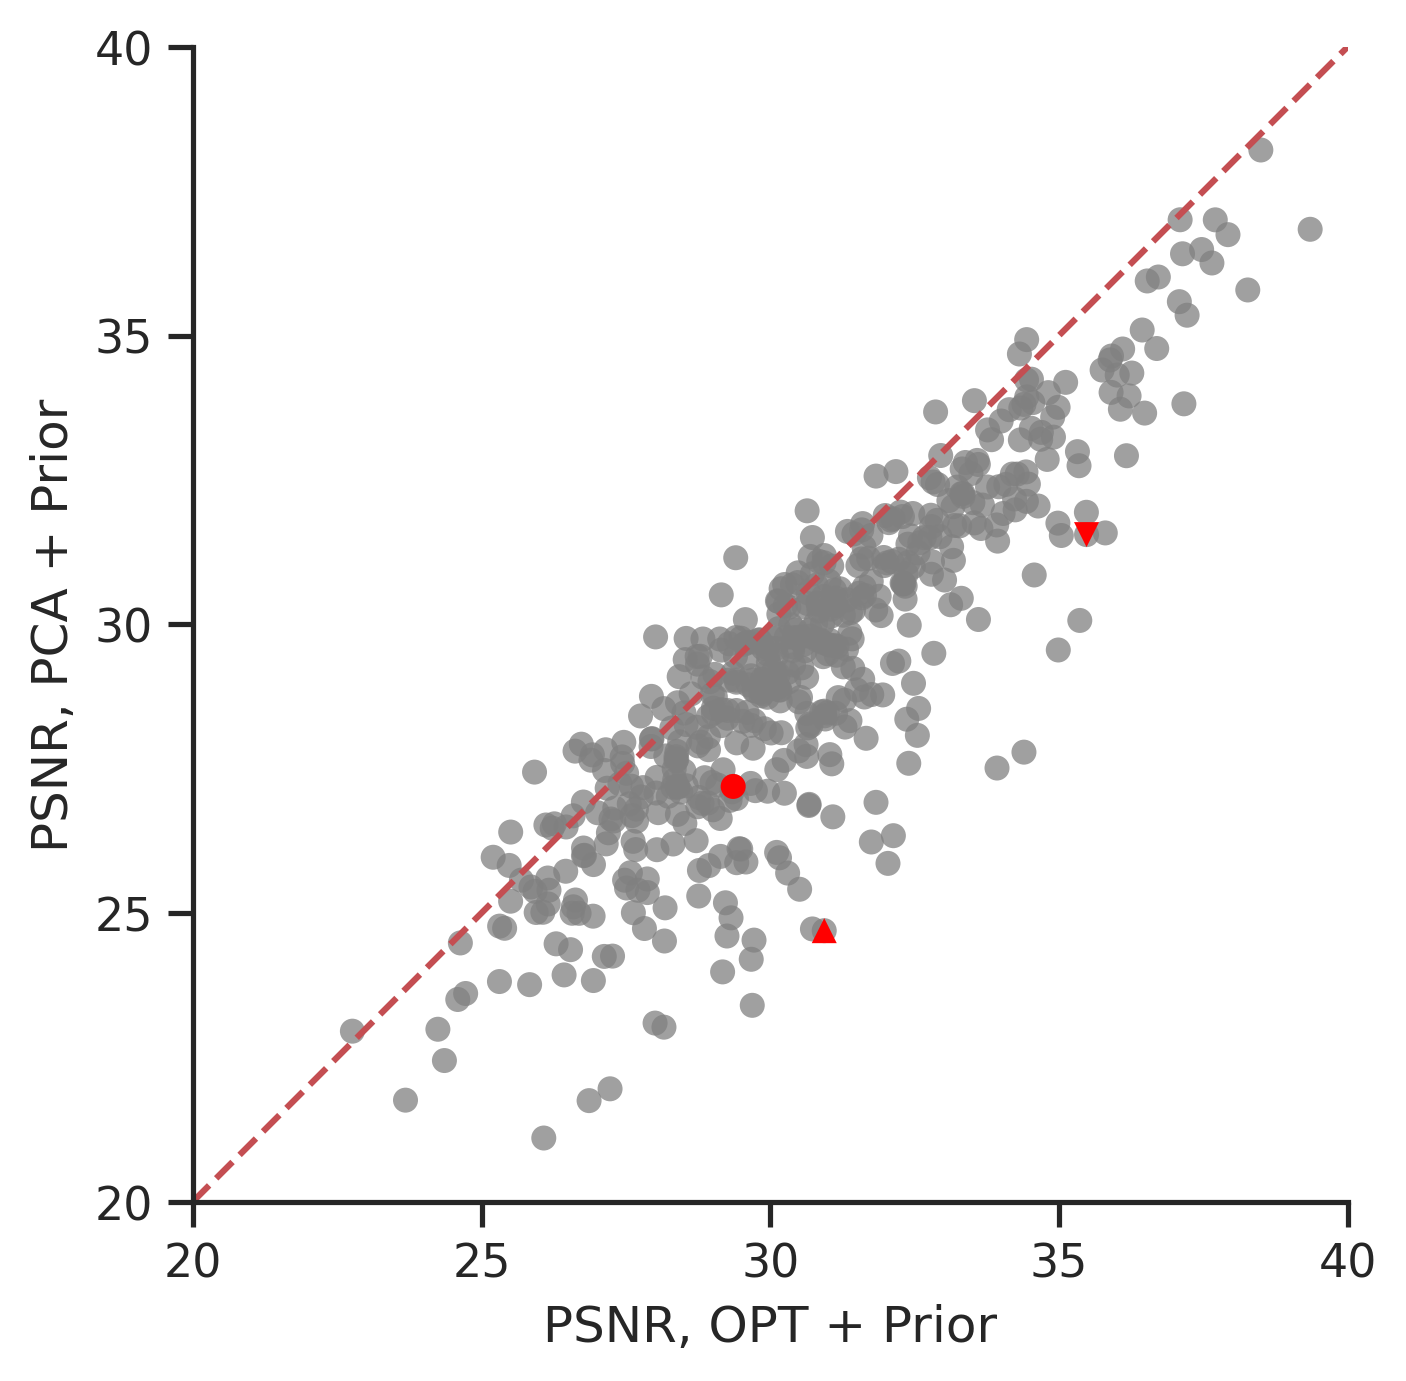

In [23]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(psnr_opt, 
            psnr_dns, 
            c='gray', alpha=0.75,
           edgecolors='none')

select_idx = [248, 476, 493]
markers = ["o", "v", "^"]
for count, idx in enumerate(select_idx):
    plt.scatter(psnr_opt[idx], 
                psnr_dns[idx], 
                c='red', alpha=1.0,
                edgecolors='none',
                marker=markers[count])

lb = 20
ub = 40
plt.plot([lb, ub], [lb, ub], '--r')

plt.xlabel('PSNR, OPT + Prior')
plt.ylabel('PSNR, PCA + Prior')

plt.axis('square')

plt.xlim([lb, ub])
plt.ylim([lb, ub])
plt.xticks(range(lb, ub + 1, 5))
plt.yticks(range(lb, ub + 1, 5))

if save_figure:
    fig_name = 'scatter_mnist'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

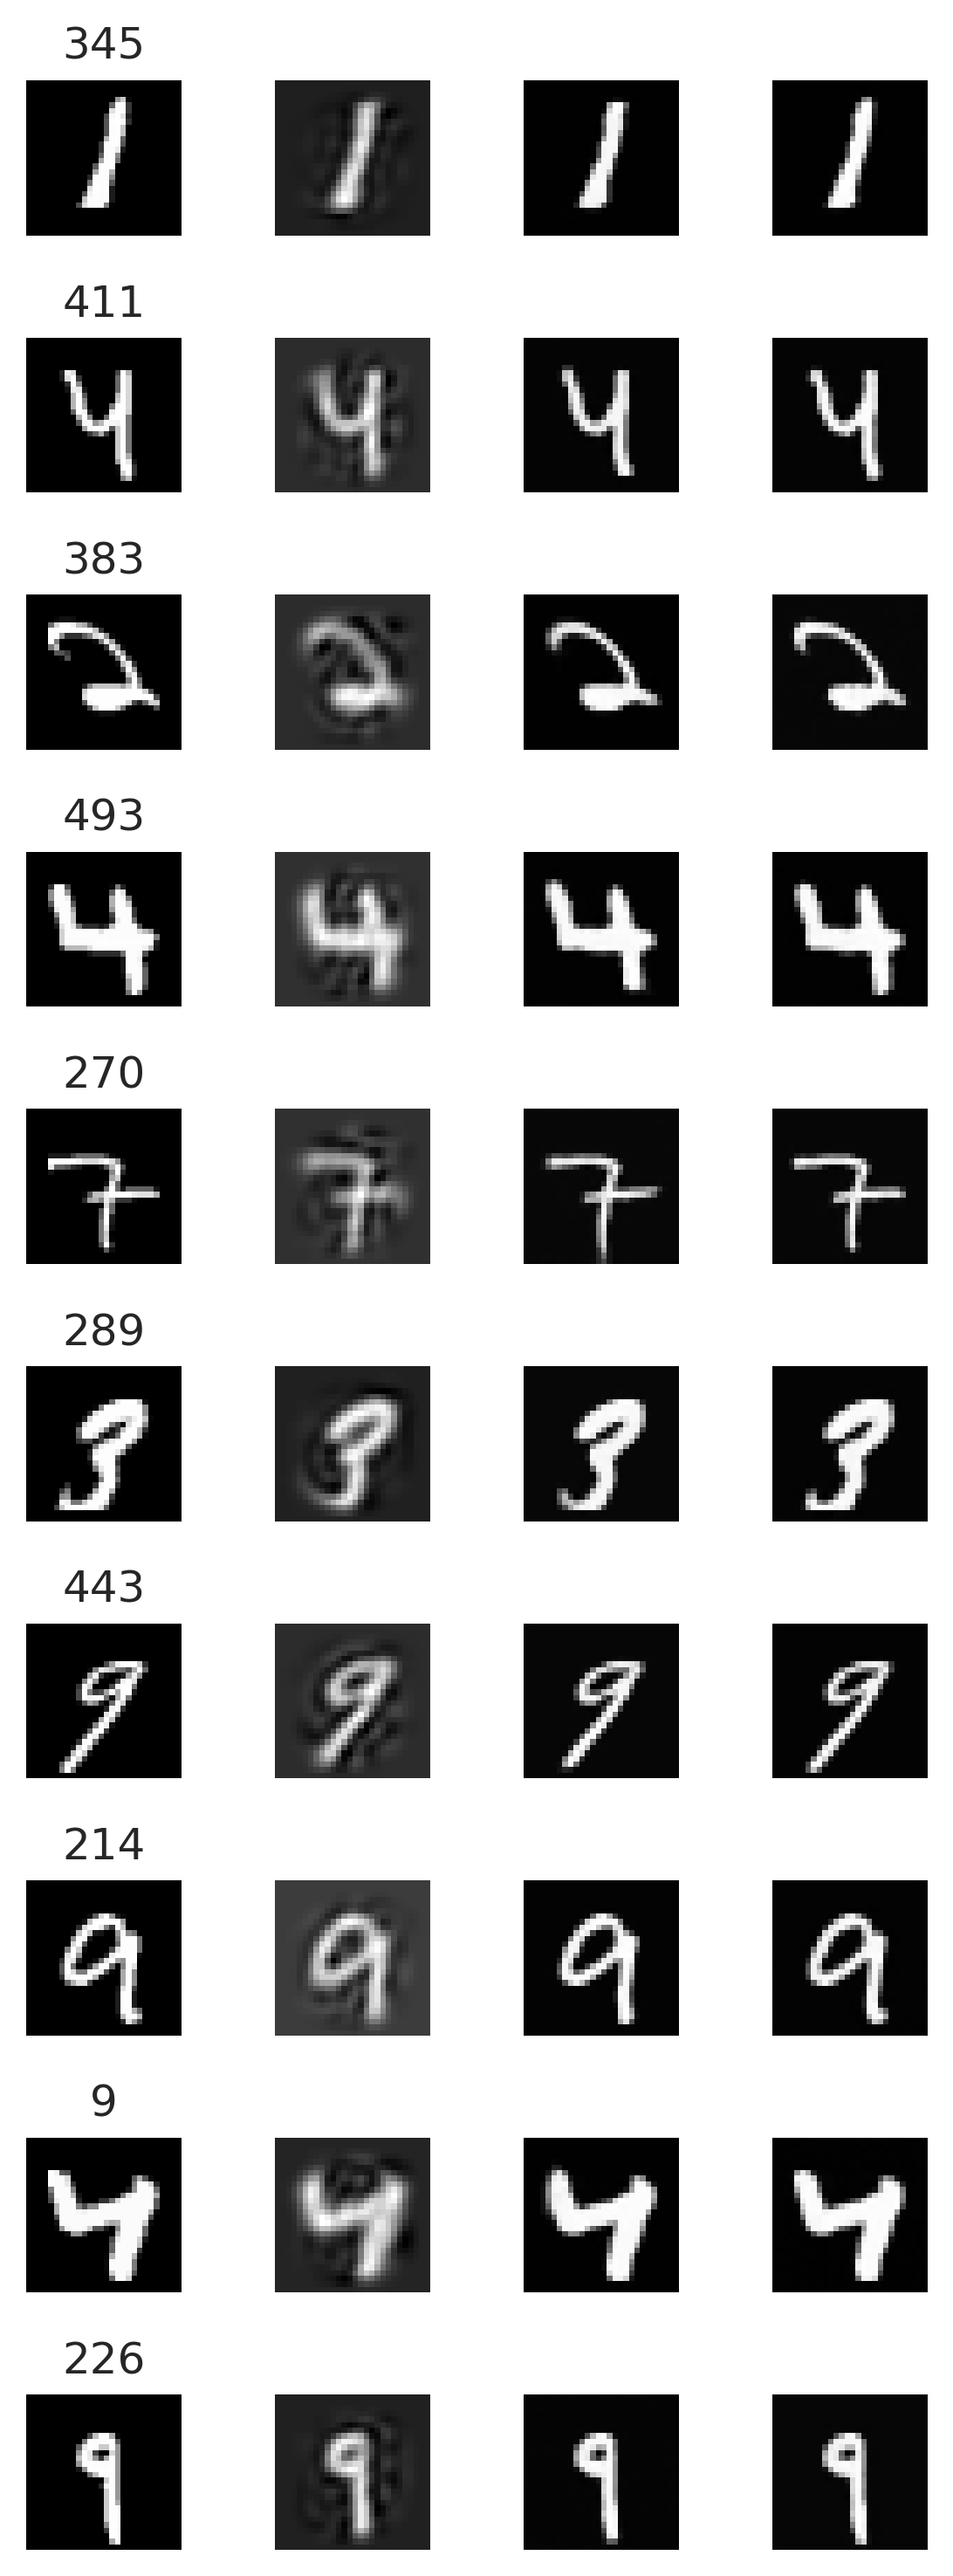

In [17]:
n_test = test_set.shape[0]
img_idx = index_select

n_row = len(img_idx)
n_col = 4
fig, axs = plt.subplots(n_row, n_col, figsize=(n_col, n_row))

all_recon = [test_numpy, recon_pca, recon_dns, recon_opt]
for idx in range(n_row):
    image_id = img_idx[idx]
    for idy in range(n_col):
        image = all_recon[idy][image_id]
        axs[idx, idy].imshow(image, cmap='gray')        
    axs[idx, 0].set_title(image_id)
    
for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()